In [7]:
# Celda 1 — Instalar dependencias no incluidas en Colab
!pip install umap-learn==0.5.6 gdown==5.2.0 -q
print("Dependencias instaladas.")

Dependencias instaladas.


In [8]:
# Celda 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Imports completados.")

Imports completados.


In [9]:
# Celda 3 — Montar Google Drive
drive.mount('/content/drive')

# Directorio de trabajo en Drive
DRIVE_PATH = '/content/drive/MyDrive/ProyectoHIGGS/'
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"Drive montado. Directorio de trabajo: {DRIVE_PATH}")

Mounted at /content/drive
Drive montado. Directorio de trabajo: /content/drive/MyDrive/ProyectoHIGGS/


In [10]:
# Celda 4 — Descargar HIGGS desde UCI (solo si no existe en Drive)
import urllib.request
import gzip
import shutil

RAW_PATH = DRIVE_PATH + 'HIGGS_raw.csv'

COLUMN_NAMES = [
    'label',
    'lepton_pt', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_b_tag',
    'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_b_tag',
    'jet3_pt', 'jet3_eta', 'jet3_phi', 'jet3_b_tag',
    'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_b_tag',
    'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb'
]

if not os.path.exists(RAW_PATH):
    print("Descargando HIGGS.csv.gz desde UCI (~2.6GB)... esto toma ~10-20 min")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"
    gz_path = DRIVE_PATH + 'HIGGS.csv.gz'
    def _progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        pct = min(downloaded / total_size * 100, 100)
        if block_num % 500 == 0:
            print(f"  {pct:.1f}% ({downloaded/1e9:.2f} GB)", end='\r')

    urllib.request.urlretrieve(url, gz_path, reporthook=_progress)
    print()  # nueva línea después de la barra de progreso
    print("Descarga completa. Descomprimiendo...")
    try:
        with gzip.open(gz_path, 'rb') as f_in:
            with open(RAW_PATH, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"Dataset guardado en {RAW_PATH}")
    finally:
        if os.path.exists(gz_path):
            os.remove(gz_path)
else:
    print(f"Dataset ya existe en {RAW_PATH}. Saltando descarga.")

Descargando HIGGS.csv.gz desde UCI (~2.6GB)... esto toma ~10-20 min
  -281395200000.0% (2.81 GB)
Descarga completa. Descomprimiendo...
Dataset guardado en /content/drive/MyDrive/ProyectoHIGGS/HIGGS_raw.csv


In [11]:
# Celda 5 — Cargar dataset completo y hacer submuestreo estratificado
SAMPLE_PATH = DRIVE_PATH + 'higgs_500k.csv'

if not os.path.exists(SAMPLE_PATH):
    print("Cargando dataset completo (11M filas)...")
    df_full = pd.read_csv(RAW_PATH, header=None, names=COLUMN_NAMES)
    print(f"Dataset completo: {df_full.shape}")

    print("Realizando submuestreo estratificado a 500K muestras...")
    df, _ = train_test_split(
        df_full,
        train_size=500_000,
        stratify=df_full['label'],
        random_state=42
    )
    df = df.reset_index(drop=True)
    df['label'] = df['label'].astype(int)
    df.to_csv(SAMPLE_PATH, index=False)
    print(f"Submuestra guardada en {SAMPLE_PATH}")
    del df_full  # liberar RAM
else:
    print(f"Submuestra ya existe. Cargando desde {SAMPLE_PATH}...")
    df = pd.read_csv(SAMPLE_PATH)

print(f"Dataset de trabajo: {df.shape}")
print(df.head(3))

Submuestra ya existe. Cargando desde /content/drive/MyDrive/ProyectoHIGGS/higgs_500k.csv...
Dataset de trabajo: (500000, 29)
   label  lepton_pt  lepton_eta  lepton_phi  missing_energy_magnitude  \
0      0   0.555433   -0.976945    1.023026                  0.535914   
1      1   0.532923   -0.727609   -0.137847                  1.090262   
2      0   0.344057   -1.493148    1.330419                  1.686226   

   missing_energy_phi   jet1_pt  jet1_eta  jet1_phi  jet1_b_tag  ...  \
0           -1.102301  0.794418 -0.858555  0.364385    2.173076  ...   
1            1.391289  0.841046  0.477265 -1.337098    1.086538  ...   
2            1.157166  1.264729  1.042687 -0.450094    2.173076  ...   

   jet4_eta  jet4_phi  jet4_b_tag      m_jj     m_jjj      m_lv     m_jlv  \
0  0.081156  1.361038    0.000000  0.916757  0.896363  0.994888  0.904785   
1  0.662467 -0.181720    3.101961  0.760842  1.047347  1.036483  0.645546   
2 -0.681710 -0.472494    0.000000  0.438440  0.847584  0.97437

## 1. Contexto del Problema

El experimento ATLAS del Large Hadron Collider (LHC) busca detectar el bosón de Higgs mediante colisiones de protones a alta energía. El problema es distinguir entre dos tipos de eventos: **señal** (producción del bosón de Higgs, label=1) y **ruido de fondo** (procesos físicos sin bosón de Higgs, label=0).

**¿Por qué Machine Learning?** El volumen de datos (~11M eventos) y la complejidad de las relaciones entre variables hace inviable la clasificación manual o por reglas. Las técnicas de ML permiten aprender patrones discriminativos directamente de los datos, superando métodos físicos clásicos.

**Paradigma:** Aprendizaje supervisado — clasificación binaria. Cada muestra tiene un label conocido (señal=1 o fondo=0) provisto por simulaciones del detector.

In [12]:
# Celda 6 — Composición de la BD
FEATURES = [c for c in df.columns if c != 'label']  # guard para ejecución fuera de orden

print("=" * 50)
print("COMPOSICIÓN DEL DATASET")
print("=" * 50)
print(f"Muestras totales:  {df.shape[0]:,}")
print(f"Variables:         {len(FEATURES)} features + 1 label")
print(f"\nTipos de datos:\n{df.dtypes.value_counts()}")
print(f"\nDatos faltantes: {df.isnull().sum().sum()} valores NaN en total")
print("\nDescripción estadística:")
df.describe().round(3)

COMPOSICIÓN DEL DATASET
Muestras totales:  500,000
Variables:         28 features + 1 label

Tipos de datos:
float64    28
int64       1
Name: count, dtype: int64

Datos faltantes: 0 valores NaN en total

Descripción estadística:


,label,lepton_pt,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b_tag,...,jet4_eta,jet4_phi,jet4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
count,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,...,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000
mean,0.530,0.990,-0.001,-0.001,0.998,0.000,0.991,0.003,-0.001,0.999,...,0.001,0.000,1.000,1.034,1.025,1.050,1.010,0.974,1.033,0.960
std,0.499,0.564,1.009,1.007,0.599,1.007,0.475,1.009,1.005,1.027,...,1.009,1.005,1.400,0.675,0.381,0.164,0.398,0.527,0.365,0.313
min,0.000,0.275,-2.435,-1.743,0.002,-1.744,0.139,-2.970,-1.741,0.000,...,-2.497,-1.743,0.000,0.100,0.271,0.133,0.229,0.059,0.335,0.356
25%,0.000,0.590,-0.742,-0.874,0.576,-0.872,0.679,-0.685,-0.868,0.000,...,-0.715,-0.871,0.000,0.791,0.846,0.986,0.767,0.675,0.820,0.771
50%,1.000,0.852,-0.001,-0.001,0.892,-0.000,0.895,0.003,-0.003,1.087,...,0.001,0.001,0.000,0.895,0.951,0.990,0.916,0.874,0.948,0.872
75%,1.000,1.233,0.739,0.870,1.292,0.873,1.171,0.691,0.868,2.173,...,0.716,0.869,3.102,1.025,1.084,1.020,1.142,1.138,1.141,1.059
max,1.000,9.451,2.435,1.743,11.031,1.743,7.400,2.969,1.741,2.173,...,2.498,1.743,3.102,27.194,14.293,5.425,8.943,12.773,8.178,6.192


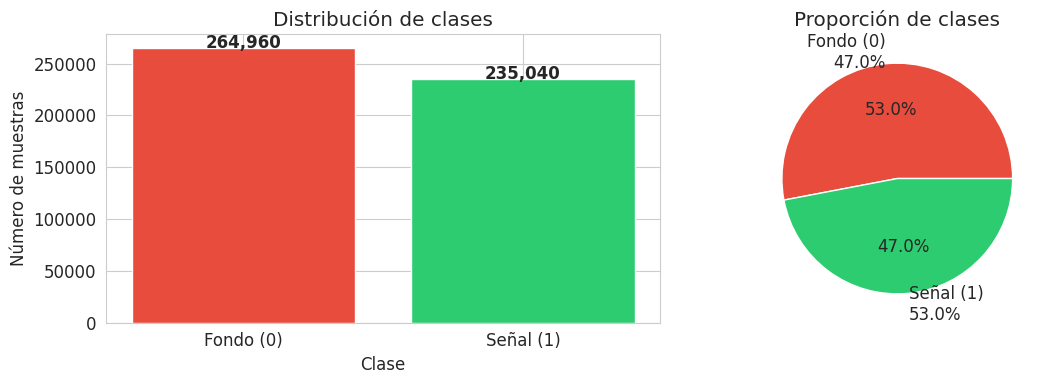

Balance: 47.0% fondo / 53.0% señal
Clases suficientemente balanceadas — no se requiere SMOTE.


In [13]:
# Celda 7 — Balance de clases
FEATURES = [c for c in df.columns if c != 'label']  # guard para ejecución fuera de orden
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(['Fondo (0)', 'Señal (1)'], class_counts.values, color=['#E74C3C', '#2ECC71'])
ax[0].set_title('Distribución de clases')
ax[0].set_ylabel('Número de muestras')
ax[0].set_xlabel('Clase')
for i, v in enumerate(class_counts.values):
    ax[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(class_pct.values,
          labels=[f'Fondo (0)\n{class_pct[0]:.1f}%', f'Señal (1)\n{class_pct[1]:.1f}%'],
          colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%')
ax[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Balance: {class_pct[0]:.1f}% fondo / {class_pct[1]:.1f}% señal")
print("Clases suficientemente balanceadas — no se requiere SMOTE.")

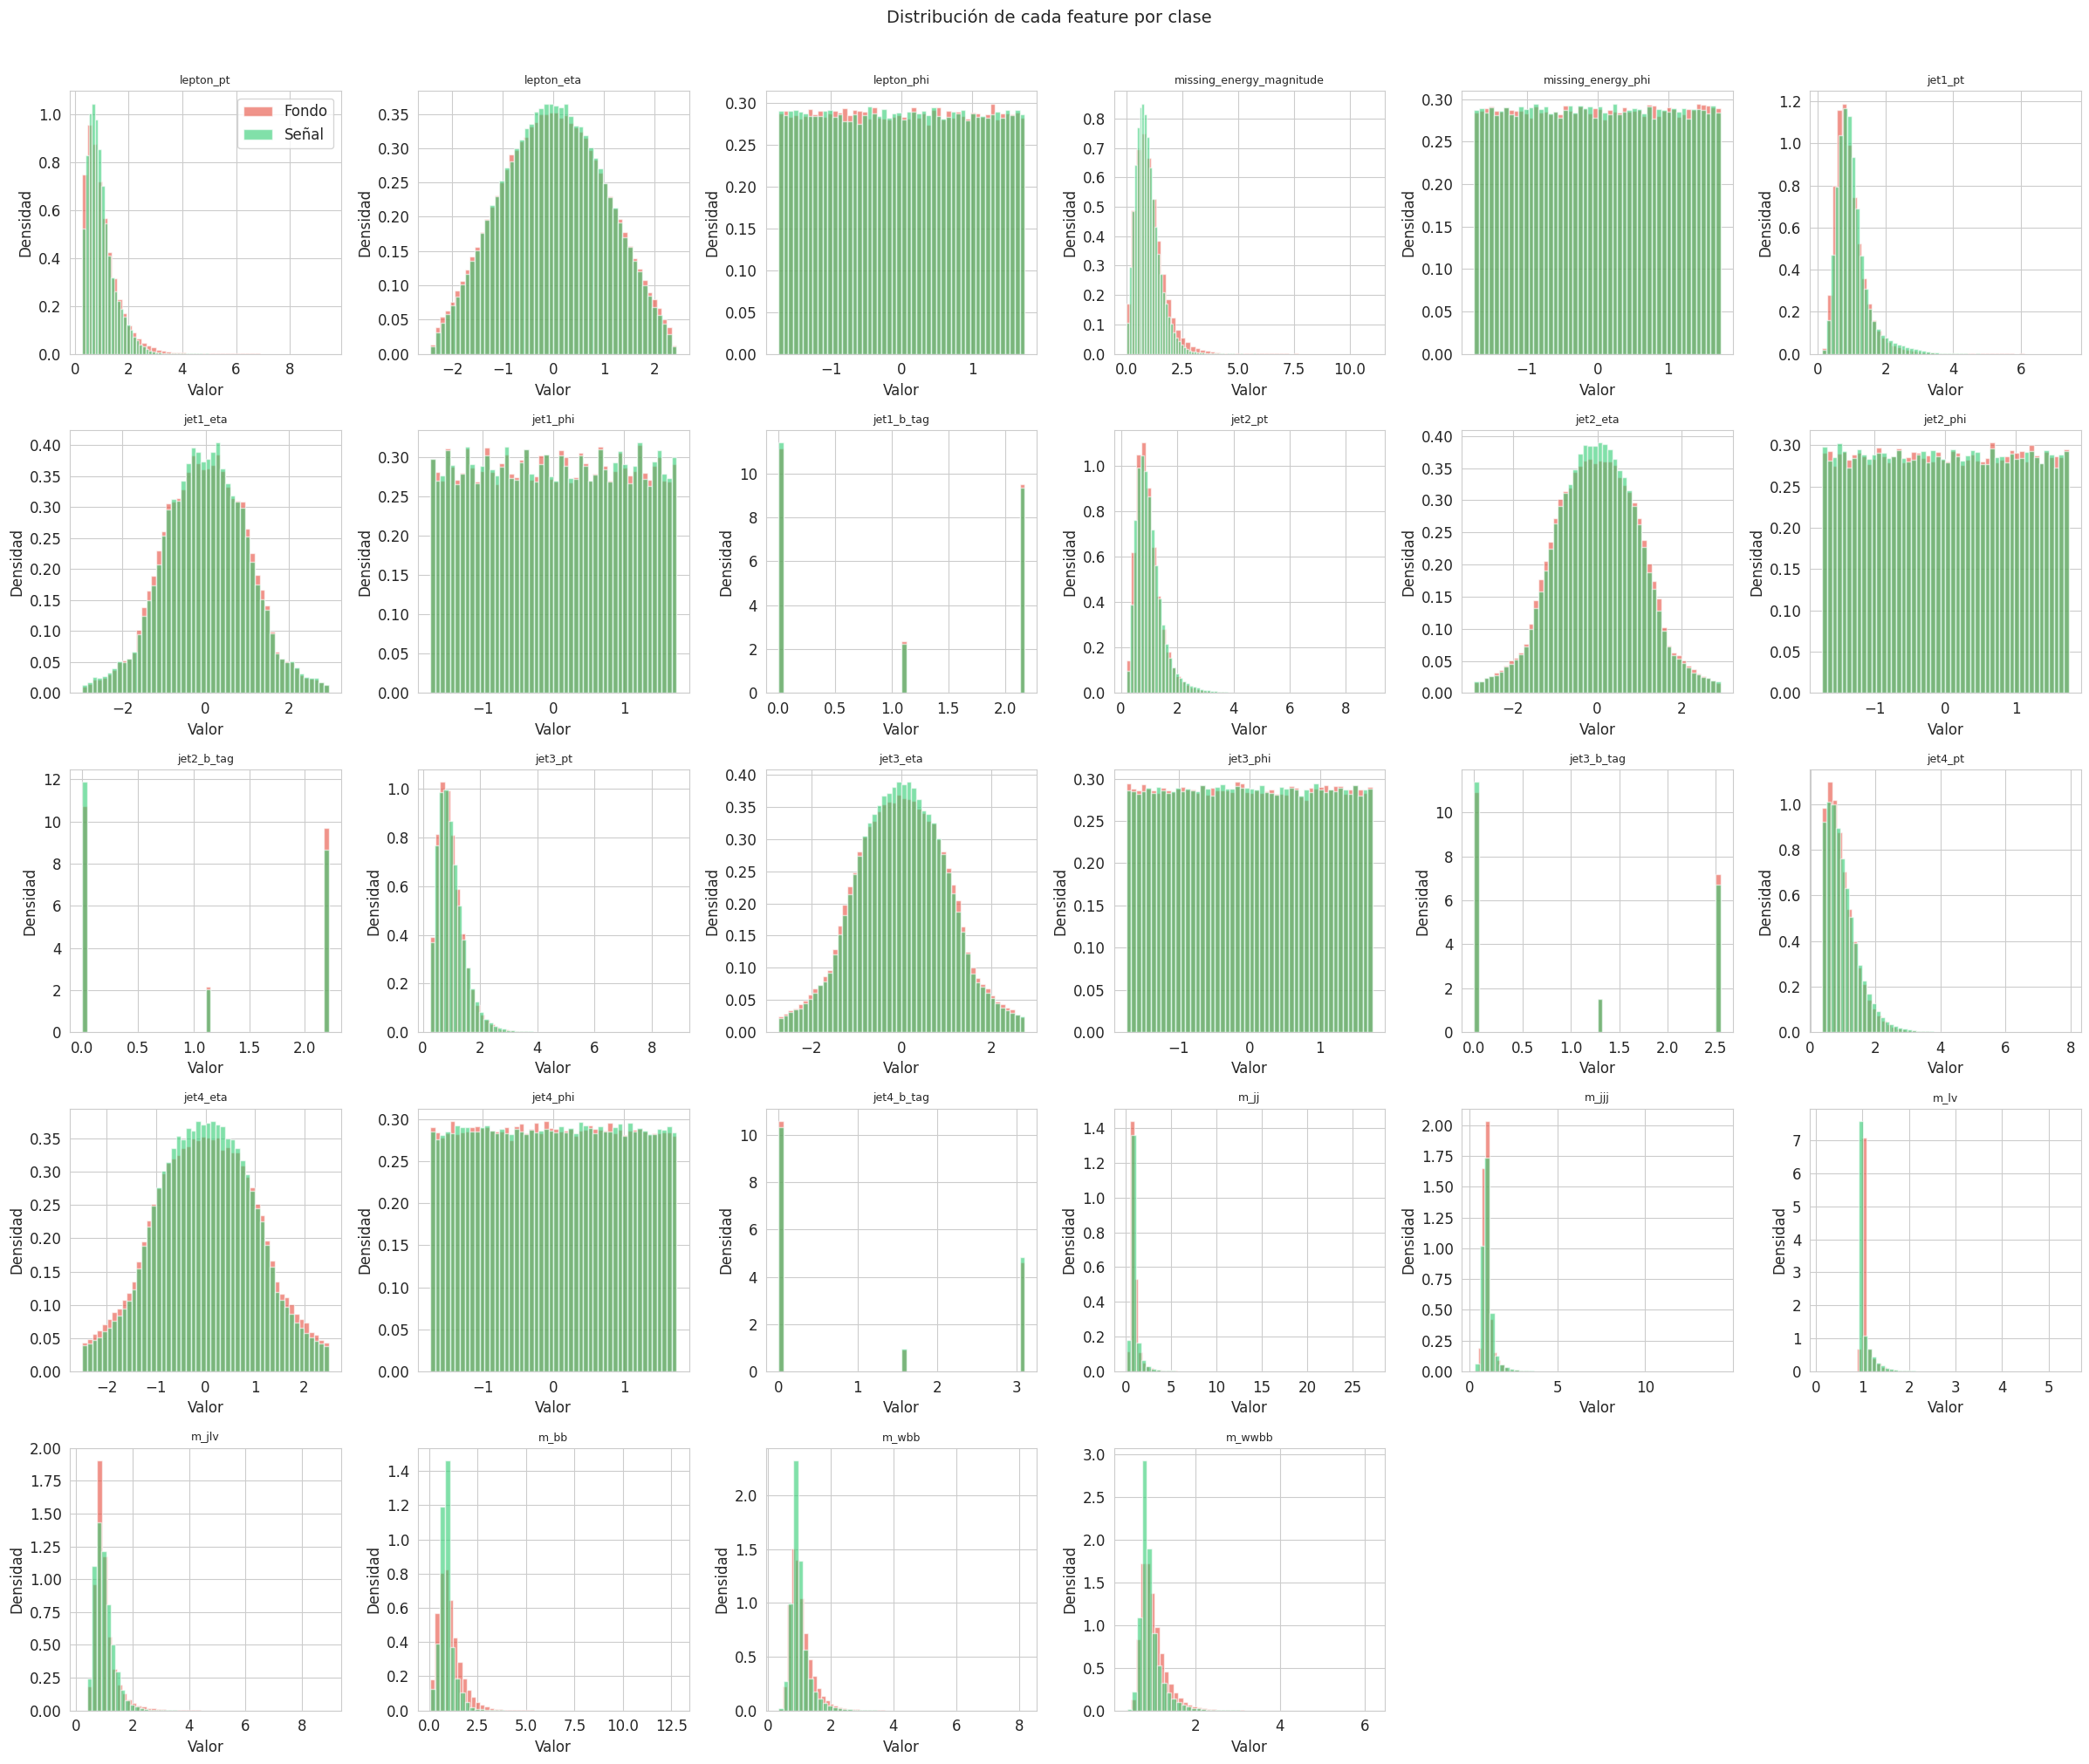

In [14]:
# Celda 8 — Histogramas por clase para cada feature
FEATURES = [c for c in df.columns if c != 'label']  # guard para ejecución fuera de orden
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[df['label']==0][feat], bins=50, alpha=0.6,
                 color='#E74C3C', label='Fondo', density=True)
    axes[i].hist(df[df['label']==1][feat], bins=50, alpha=0.6,
                 color='#2ECC71', label='Señal', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')

for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

axes[0].legend()
plt.suptitle('Distribución de cada feature por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_univariado.png', dpi=120, bbox_inches='tight')
plt.show()

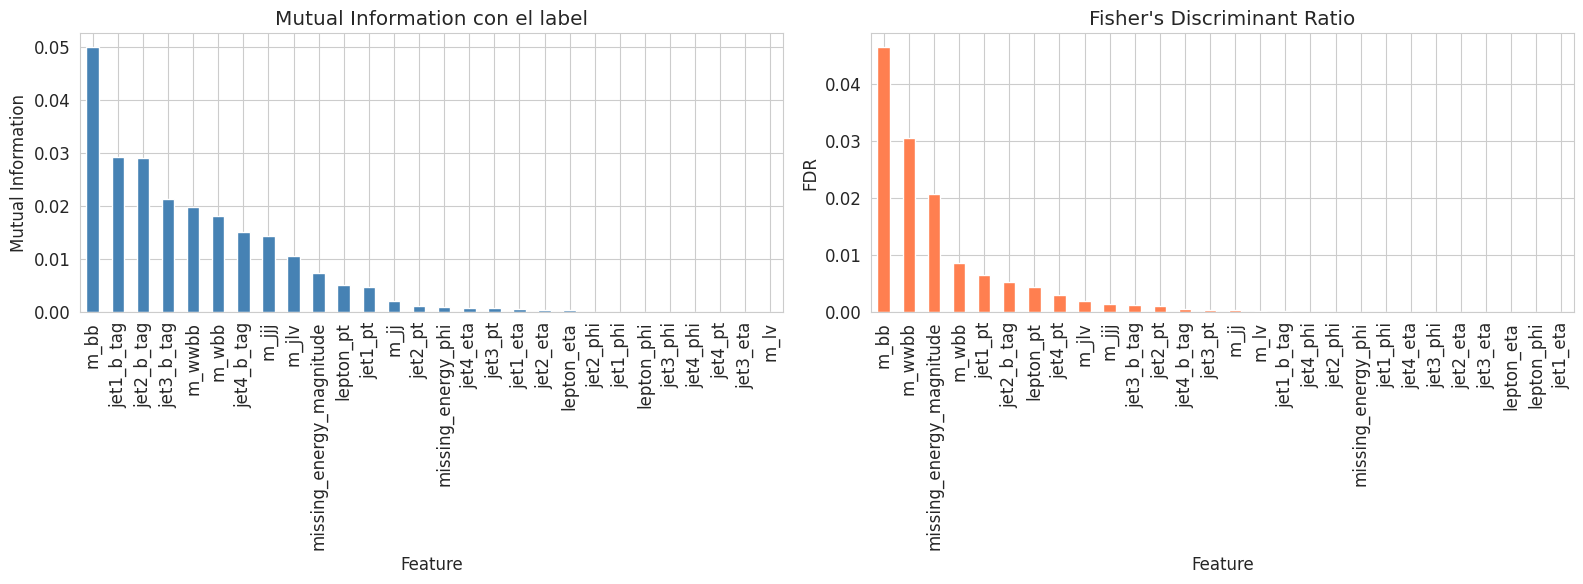


Features candidatas a eliminar (MI < 0.01):
['missing_energy_magnitude', 'lepton_pt', 'jet1_pt', 'm_jj', 'jet2_pt', 'missing_energy_phi', 'jet4_eta', 'jet3_pt', 'jet1_eta', 'jet2_eta', 'lepton_eta', 'jet2_phi', 'jet1_phi', 'lepton_phi', 'jet3_phi', 'jet4_phi', 'jet4_pt', 'jet3_eta', 'm_lv']


In [15]:
# Celda 9 — Mutual Information y Fisher's Discriminant Ratio
from sklearn.feature_selection import mutual_info_classif

X = df[FEATURES].values
y = df['label'].values

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)

# Fisher's Discriminant Ratio
mu1 = df[df['label']==1][FEATURES].mean()
mu0 = df[df['label']==0][FEATURES].mean()
std1 = df[df['label']==1][FEATURES].std()
std0 = df[df['label']==0][FEATURES].std()
fisher = (mu1 - mu0)**2 / (std1**2 + std0**2 + 1e-10)
fisher_series = fisher.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mi_series.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information con el label')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Mutual Information')
axes[0].tick_params(axis='x', rotation=90)

fisher_series.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Fisher's Discriminant Ratio")
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('FDR')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_discriminacion.png', dpi=150, bbox_inches='tight')
plt.show()

UMBRAL_MI = 0.01
candidatas_eliminar = mi_series[mi_series < UMBRAL_MI].index.tolist()
print(f"\nFeatures candidatas a eliminar (MI < {UMBRAL_MI}):")
print(candidatas_eliminar if candidatas_eliminar else "Ninguna — todas tienen MI relevante.")

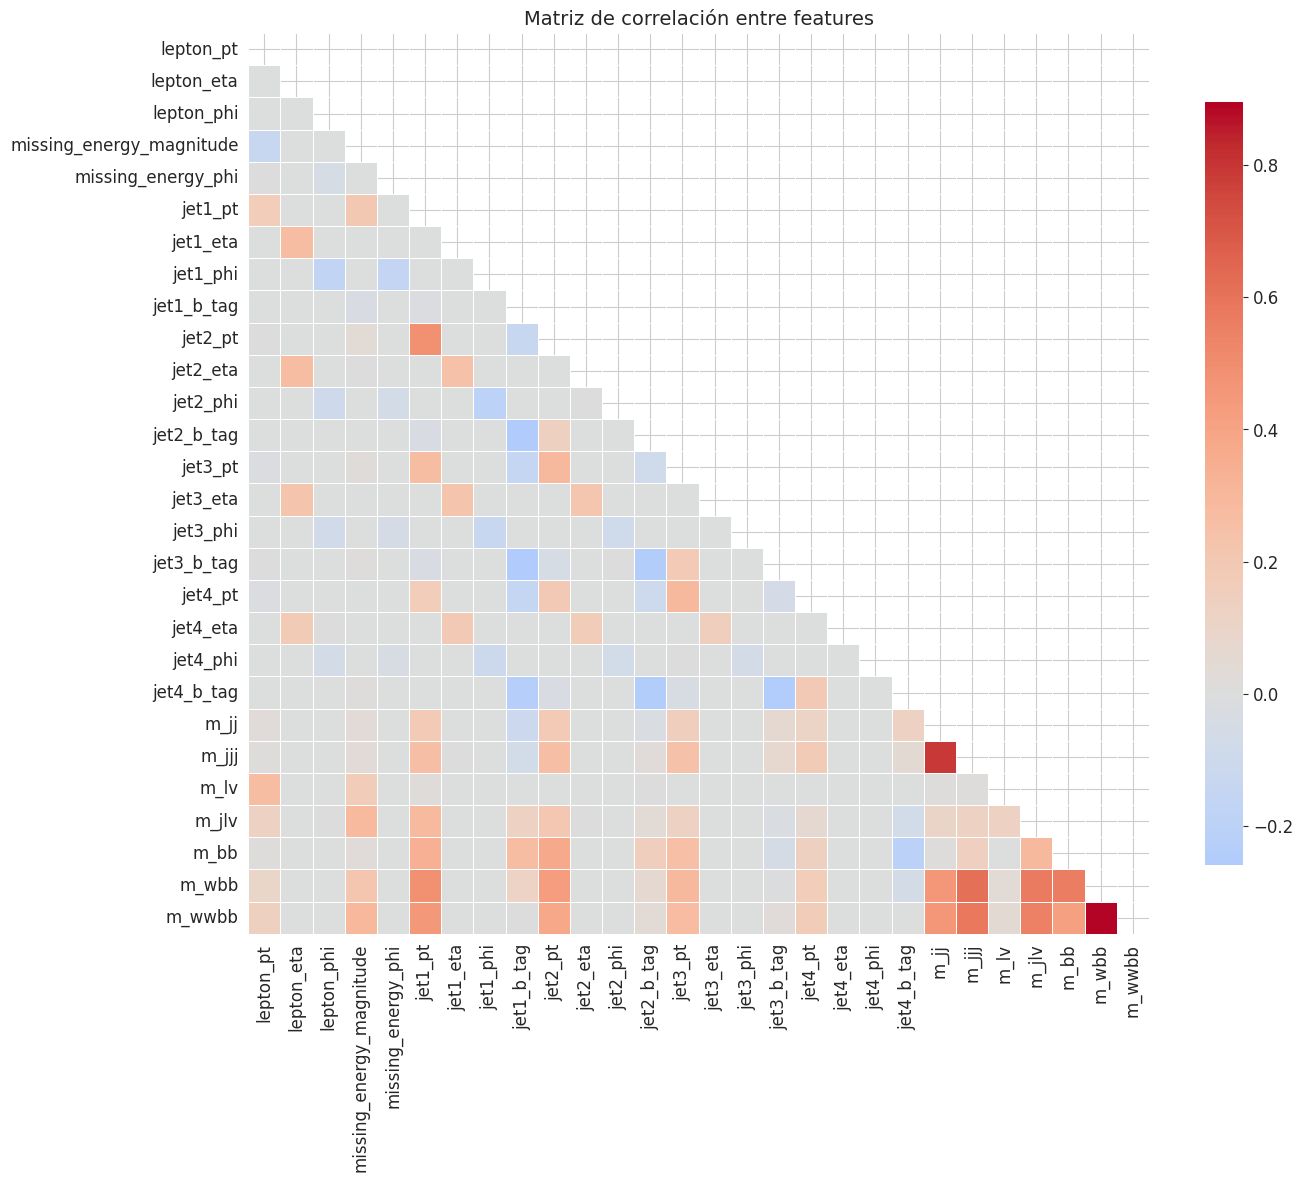

In [16]:
# Celda 10 — Matriz de correlación entre features
corr_matrix = df[FEATURES].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de correlación entre features', fontsize=14)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'fig_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Celda 11 — Split estratificado 70/15/15 y guardado en Drive
X = df[FEATURES].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val:   {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nBalance train — Señal: {y_train.mean()*100:.1f}%, Fondo: {(1-y_train.mean())*100:.1f}%")

np.save(DRIVE_PATH + 'X_train.npy', X_train)
np.save(DRIVE_PATH + 'X_val.npy', X_val)
np.save(DRIVE_PATH + 'X_test.npy', X_test)
np.save(DRIVE_PATH + 'y_train.npy', y_train)
np.save(DRIVE_PATH + 'y_val.npy', y_val)
np.save(DRIVE_PATH + 'y_test.npy', y_test)
np.save(DRIVE_PATH + 'feature_names.npy', np.array(FEATURES))
print("\nSplits guardados en Drive.")

Train: 350,000 muestras (70%)
Val:   75,000 muestras (15%)
Test:  75,000 muestras (15%)

Balance train — Señal: 53.0%, Fondo: 47.0%

Splits guardados en Drive.


## 7. Métricas de Desempeño

**Métrica principal: AUC-ROC**
Área bajo la curva ROC. Mide la capacidad del modelo de distinguir entre clases independientemente del umbral de decisión. Valor de 0.5 = clasificador aleatorio, 1.0 = clasificación perfecta. Se elige como métrica principal porque las clases están balanceadas (~53/47%) y porque es estándar en la literatura de HIGGS (Baldi et al., 2014 reportaron AUC-ROC de 0.885).

**Métricas secundarias:**
- **Precision:** Proporción de predicciones positivas correctas entre todas las predicciones positivas. Mide la pureza de la señal detectada — en el contexto de física de partículas: "si el clasificador dice que es un bosón de Higgs, ¿qué tan confiable es esa afirmación?". Alta precisión implica baja tasa de falsos positivos.
- **Recall:** Proporción de eventos de señal correctamente identificados del total de señales reales. Mide la eficiencia de detección — en física: "de todas las partículas Higgs que pasaron por el detector, ¿cuántas logramos identificar?". Alto recall implica baja tasa de falsos negativos.
- **F1-Score:** Media armónica de precisión y recall. Balancea pureza y eficiencia en una sola métrica. Útil cuando no hay preferencia explícita entre minimizar falsos positivos y falsos negativos.
- **Accuracy:** Fracción de predicciones correctas sobre el total. Interpretable dado el balance de clases (~53/47%).

**Intervalos de confianza:** Estimados como media ± 2σ de los k=5 folds del K-Fold Cross-Validation estratificado (≈95% de confianza).